# Modellverständnis – Theorie und Demos
## Projekt: Predictive Analytics im Radsport – Grand Tour Stage Ranking

### Einleitung & Zielsetzung
Dieses Notebook ist eine **didaktische Vorlage**: Es geht hier *nicht* darum, eine vollständige Modellpipeline aufzubauen oder finale Ergebnisse zu liefern, sondern darum, die wichtigsten Modellklassen für das Cycling-Stage-Prediction-Problem konzeptionell zu verstehen. Theorie-Markdown und kurze Code-Demos wechseln sich daher bewusst ab.

Wir betrachten vier Modellfamilien, die jeweils eine andere Perspektive auf tabellarische Sportdaten haben:

1. **XGBoost-Klassifikator** – klassisches Gradient Boosting auf Entscheidungsbäumen, der typische *Tabular-Workhorse*.
2. **Explainable Boosting Machine (EBM)** – ein interpretierbares Glass-Box-Modell aus der `interpret`-Bibliothek von Microsoft.
3. **TabPFN** – ein *Prior-Data-Fitted Network* (Transformer), das bayesianische Inferenz approximiert und ohne klassisches Training auskommt.
4. **XGBRanker** – ein Learning-to-Rank-Modell, das direkt auf das eigentliche Use-Case (Etappenrang vorhersagen) zugeschnitten ist.

### Abhängigkeiten
Genutzt werden `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `xgboost`, `interpret`, `tabpfn` (lokales Paket), `tabpfn-client` (Cloud-Inferenz, bevorzugt), `shap` und `lime`. Die ersten vier sind im Projekt-`venv` bereits installiert; die ML-spezifischen Pakete müssen ggf. nachinstalliert werden. Die folgende Zelle enthält dafür einen auskommentierten Hinweis – sie wird **nicht** automatisch ausgeführt.

In [1]:
# Bei Bedarf einmalig im aktiven venv ausführen:
# !pip install xgboost interpret tabpfn tabpfn-client shap lime

### 1. Setup & Daten laden
Wir laden den um Koordinaten und Wetterdaten angereicherten Master-Datensatz (`data/processed/cleaned_master_data_with_coordinates_and_weather.pkl`) und leiten in einer einzigen kompakten Zelle alle Größen ab, die in den späteren Demos gebraucht werden. Der Datensatz enthält neben den Spalten aus Notebook 01 zusätzlich `stage_nr`, `date`, Start-/Ziel-Koordinaten sowie 12 Wetterspalten – diese werden im Demo-Notebook bewusst nicht in das Feature-Set aufgenommen, stehen aber für spätere Notebooks zur Verfügung. Folgende Anpassungen am ursprünglichen Datensatz sind nötig:

- **`rank` → `rank_num`**: Numerische Konvertierung der Platzierungsspalte; Zeilen mit nicht-numerischem Rang (z. B. `DNF`, `OTL`) werden verworfen.
- **`distance` → `distance_km`**: Strings wie `"19 km"` werden in Floats umgewandelt.
- **`vertical_meters` → `vertical_m`** und **`profile_score` → `profile_score_num`**: Sicherheitshalber `to_numeric` mit `errors='coerce'`.
- **`avg_speed`**: `"54.676 km/h"` → `54.676` als `float`.
- **Alter**: `age = year − Jahr aus birthdate`.
- **Klassifikations-Target `top10`**: binär, `1` falls `rank_num <= 10`.
- **Ranking-Target**: `rank_num` als Label, Etappen-ID als Tupel `(race, year, stage_nr)` für den `group=`-Vektor von XGBoost.
- **Feature-Set**: `height`, `weight`, `age`, `distance_km`, `vertical_m`, `profile_score_num`, `one_day_races`, `gc`, `time_trial`, `sprint`, `climber`, `hills`.
- **Zeitbasierter Split**: `year < 2020` → Train, `year >= 2020` → Test (klein gehalten, rein zu Demo-Zwecken).

Pfade werden bewusst relativ über `pathlib` referenziert, damit das Notebook portabel bleibt.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_PATH = Path('../../data/processed/cleaned_master_data_with_coordinates_and_weather.pkl')
df = pd.read_pickle(DATA_PATH)

# 1) Rang numerisch machen und ungültige Zeilen entfernen
df['rank_num'] = pd.to_numeric(df['rank'], errors='coerce')
df = df.dropna(subset=['rank_num']).copy()
df['rank_num'] = df['rank_num'].astype(int)

# 2) Etappen-Features parsen ('19 km' -> 19.0 etc.)
df['distance_km'] = (df['distance'].astype(str)
                       .str.replace(' km', '', regex=False)
                       .replace({'-': np.nan})
                       .astype(float))
df['vertical_m'] = pd.to_numeric(df['vertical_meters'], errors='coerce')
df['avg_speed_kmh'] = (df['avg_speed'].astype(str)
                         .str.replace(' km/h', '', regex=False)
                         .replace({'-': np.nan})
                         .astype(float))
df['profile_score_num'] = pd.to_numeric(df['profile_score'], errors='coerce')

# 3) Alter aus birthdate und Etappenjahr ableiten
df['birth_year'] = pd.to_datetime(df['birthdate'], errors='coerce').dt.year
df['age'] = df['year'] - df['birth_year']

# 4) Klassifikations-Target: Top-10-Platzierung
df['top10'] = (df['rank_num'] <= 10).astype(int)

# 5) Feature-Set definieren und Zeilen mit fehlenden Werten verwerfen
FEATURES = ['height', 'weight', 'age', 'distance_km', 'vertical_m',
            'profile_score_num', 'one_day_races', 'gc',
            'time_trial', 'sprint', 'climber', 'hills']
df_model = df.dropna(subset=FEATURES + ['year']).copy()

# 6) Zeitbasierter Split (klein gehalten, nur für Demo-Zwecke)
train = df_model[df_model['year'] < 2020]
test  = df_model[df_model['year'] >= 2020]
X_train, y_train = train[FEATURES], train['top10']
X_test,  y_test  = test[FEATURES],  test['top10']

# 7) Gruppen-Vektor für Learning-to-Rank: pro Etappe eine Gruppe
group_keys = ['race', 'year', 'stage_nr']
train_r = train.sort_values(group_keys)
test_r  = test.sort_values(group_keys)
groups_train = train_r.groupby(group_keys, sort=False).size().to_numpy()
groups_test  = test_r.groupby(group_keys, sort=False).size().to_numpy()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Etappen Train: {len(groups_train)}, Etappen Test: {len(groups_test)}')

Train: (155308, 12), Test: (58487, 12)
Etappen Train: 904, Etappen Test: 370


### 2. XGBoost-Klassifikator

**Idee.** XGBoost (*eXtreme Gradient Boosting*) ist eine effiziente Implementierung von **Gradient Boosting auf Entscheidungsbäumen**. Das Modell wird *additiv* aufgebaut: In Iteration $m$ wird ein neuer Baum $h_m$ so gewählt, dass er den Residualfehler des bisherigen Ensembles möglichst gut korrigiert:

$$ F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x) $$

Dabei ist $\eta$ die Lernrate (*Shrinkage*). Die Wahl von $h_m$ beruht auf einer Taylor-Approximation 2. Ordnung der Verlustfunktion $\ell$, sodass jeder Baum die **Gradienten** $g_i = \partial \ell / \partial F(x_i)$ und **Hessian-Werte** $h_i = \partial^2 \ell / \partial F(x_i)^2$ der Trainingspunkte als Splitkriterium verwendet. Hinzu kommen Regularisierungsterme auf die Anzahl Blätter und die Blattgewichte, die Overfitting eindämmen.

**Stärken.**
- State-of-the-Art-Performance auf tabellarischen Daten ohne aufwendiges Feature-Engineering.
- Skalierbar, robust gegen unterschiedliche Skalen, fehlertolerant gegenüber `NaN`s.
- Liefert Feature-Importances als Nebenprodukt.

**Schwächen.**
- *Black Box*: einzelne Vorhersagen sind nicht direkt interpretierbar (Hilfe nur über SHAP o. ä.).
- Relativ viele Hyperparameter, sensitiv gegenüber starkem Klassen-Ungleichgewicht.

Wir nutzen XGBoost hier als Baseline-Klassifikator für `top10`.

XGBoost  Accuracy: 0.939 | ROC-AUC: 0.853


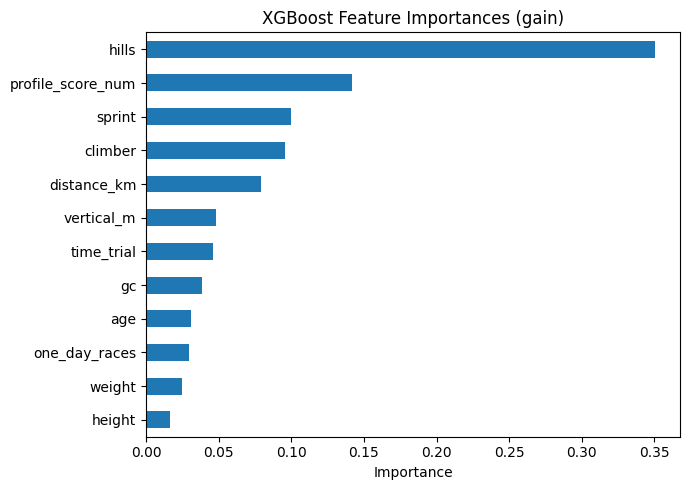

In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
)
xgb_clf.fit(X_train, y_train)

xgb_pred  = xgb_clf.predict(X_test)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_proba)
print(f'XGBoost  Accuracy: {xgb_acc:.3f} | ROC-AUC: {xgb_auc:.3f}')

# Feature Importances als Plot
imp = pd.Series(xgb_clf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax)
ax.set_title('XGBoost Feature Importances (gain)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 3. Explainable Boosting Machine (EBM)

**Idee.** Eine EBM ist ein **Generalized Additive Model with Interactions** (kurz **GA²M**) und gehört zu den *Glass-Box*-Modellen aus der `interpret`-Bibliothek von Microsoft. Anders als XGBoost, das beliebig komplexe Bäume auf allen Features gemeinsam baut, zerlegt die EBM die Vorhersage in eine *additive* Form aus eindimensionalen Shape-Funktionen $f_j$ und (optionalen) paarweisen Interaktionen $f_{jk}$:

$$ g(\mathbb{E}[y \mid x]) = \beta_0 + \sum_{j} f_j(x_j) + \sum_{j<k} f_{jk}(x_j, x_k) $$

Hierbei ist $g$ die Link-Funktion (z. B. Logit für Klassifikation). Trainiert wird per **Round-Robin-Boosting**: Es wird sehr viele Iterationen lang abwechselnd *je ein Feature* mit einem kleinen Baum geboostet, sodass am Ende für jedes Feature eine glatte, klar darstellbare Funktion $f_j$ entsteht.

**Vergleich zu XGBoost.**
- *Genauigkeit*: oft auf Augenhöhe mit XGBoost auf tabellarischen Daten.
- *Interpretierbarkeit*: jede Funktion $f_j$ kann direkt als Plot gezeigt werden („Wie wirkt `age` auf die Top-10-Wahrscheinlichkeit?"), ohne Post-hoc-Methoden wie SHAP.
- *Trainingszeit*: in der Regel langsamer als XGBoost wegen vieler Boosting-Runden pro Feature.

Wir trainieren einen `ExplainableBoostingClassifier` auf demselben Klassifikations-Task und schauen auf die globalen Shape-Funktionen.

EBM      Accuracy: 0.938 | ROC-AUC: 0.848


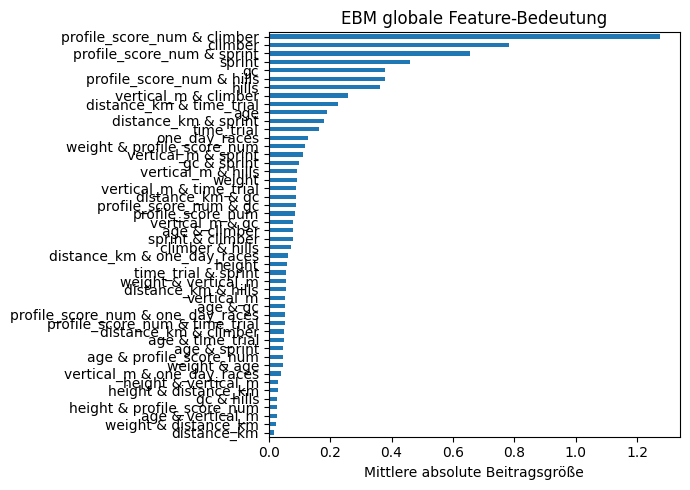

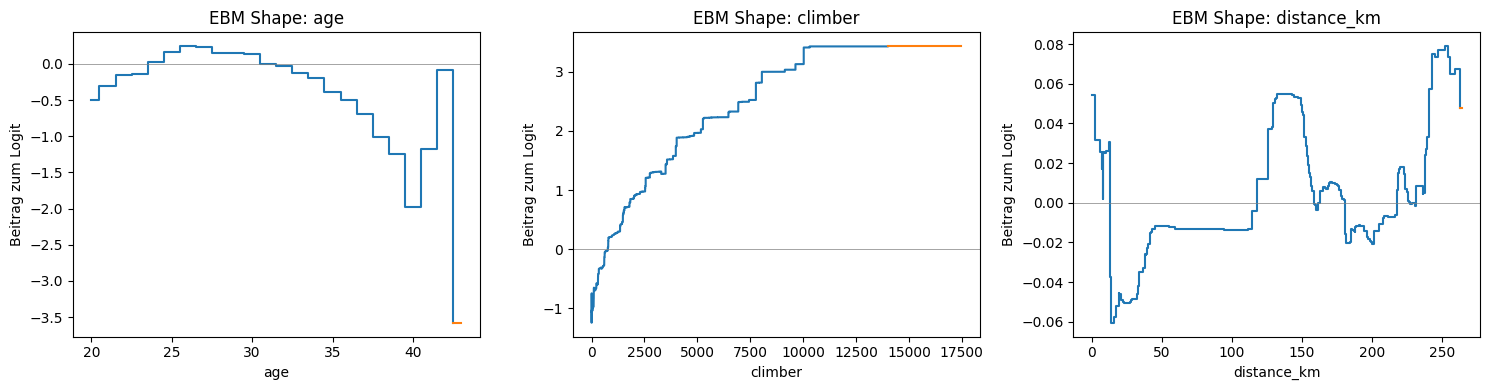

In [4]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)

ebm_pred  = ebm.predict(X_test)
ebm_proba = ebm.predict_proba(X_test)[:, 1]
ebm_acc = accuracy_score(y_test, ebm_pred)
ebm_auc = roc_auc_score(y_test, ebm_proba)
print(f'EBM      Accuracy: {ebm_acc:.3f} | ROC-AUC: {ebm_auc:.3f}')

# Globale Erklärung: Shape-Funktion für jedes Feature
global_exp = ebm.explain_global()
summary = global_exp.data()  # enthält u.a. 'names' und 'scores' (mittlere |Beitrag|)
feat_scores = pd.Series(summary['scores'], index=summary['names']).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
feat_scores.plot.barh(ax=ax)
ax.set_title('EBM globale Feature-Bedeutung')
ax.set_xlabel('Mittlere absolute Beitragsgröße')
plt.tight_layout()
plt.show()

# Beispiel: Shape-Funktionen mehrerer Features nebeneinander plotten.
# Zeigt schoen, dass jedes f_j eine eigene, glatte Funktion ist - das macht
# eine EBM zu einer "Glass-Box": jede Kurve ist ein direkter Erklaerungsblock.
demo_features = ['age', 'climber', 'distance_km']
fig, axes = plt.subplots(1, len(demo_features), figsize=(15, 4))
for ax, feat in zip(axes, demo_features):
    feat_idx = FEATURES.index(feat)
    shape_data = global_exp.data(feat_idx)
    names = np.asarray(shape_data['names'])
    scores = np.asarray(shape_data['scores'])
    if len(names) == len(scores) + 1:
        # Stetiges Feature: 'names' enthaelt Bin-Kanten, 'scores' die Werte je Bin -> Step-Plot
        ax.step(names[:-1], scores, where='post')
        ax.plot([names[-2], names[-1]], [scores[-1], scores[-1]])
    else:
        # Kategoriales Feature: gleiche Laenge -> regulaerer Plot
        ax.plot(names, scores, marker='o')
    ax.set_title(f"EBM Shape: {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel('Beitrag zum Logit')
    ax.axhline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

# Alternativ interaktiv im Notebook (Dashboard):
# from interpret import show
# show(global_exp)

### 4. TabPFN

**Idee.** TabPFN ist ein **Prior-Data-Fitted Network**: ein **Transformer**, der einmalig (von den Autoren) auf *Millionen synthetisch generierter Datensätze* vortrainiert wurde. Dabei lernt das Netz, das Verhalten eines bayesianischen Posterior-Predictive auf strukturell ähnlichen Datensätzen zu *approximieren*. Im Inferenzschritt füttert man Trainings- und Testdaten gemeinsam in das Netz – das Modell führt also **In-Context-Learning** durch und gibt direkt die Klassenwahrscheinlichkeiten aus, **ohne** dass auf den eigenen Daten weiter trainiert werden müsste:

$$ p(y_\text{test} \mid x_\text{test}, D_\text{train}) \approx \text{TabPFN}_\theta(x_\text{test}, D_\text{train}) $$

**Limits.**
- Für kleine bis mittelgroße tabellarische Datensätze gedacht (in der Originalvariante typischerweise $\le 1000$ Trainingszeilen, $\le 100$ Features, $\le 10$ Klassen). Wir samplen daher gezielt eine kleinere Trainingsmenge.
- Aktuell primär für Klassifikation entwickelt; Regressions-Varianten existieren, sind aber weniger ausgereift.
- Inferenz auf GPU deutlich schneller als auf CPU, kann aber speicherintensiv werden.

**Bezug zu AutoML.** TabPFN ist gewissermaßen ein „Foundation-Model für Tabular-Daten": man umgeht den klassischen Modellauswahl-/Tuning-Loop und nutzt die im Prior-Training gelernten Inductive Biases.

> **Hinweis zur Lizenz / Auth.** Ab TabPFN ≥ 2.x ist einmalig ein kostenloser API-Token nötig (Account auf [https://ux.priorlabs.ai](https://ux.priorlabs.ai), Lizenz akzeptieren, Token aus dem Account-Tab kopieren). Wir verwenden bevorzugt das Paket `tabpfn-client`, das Inferenz **in der Cloud** macht und die Modellgewichte nicht lokal lädt. Den Token speichern wir in `Dokumentation/tabpfn_token.env` (Inhalt: `TABPFN_TOKEN=<dein-api-key>`). Diese Datei liegt im gitignorierten `Dokumentation/`-Ordner und wird nie versioniert. Alternativ funktioniert auch eine Umgebungsvariable `TABPFN_TOKEN` (z. B. `export TABPFN_TOKEN=...` oder in einer Notebook-Zelle vor dem Aufruf `os.environ["TABPFN_TOKEN"] = "..."`). Ohne Token überspringt die Demo-Zelle den Schritt sauber und setzt die Metriken auf `NaN`.

Hier vergleichen wir TabPFN auf einer kleinen Stichprobe gegen XGBoost und EBM.

In [5]:
import os
from pathlib import Path
import numpy as np

# 1) TABPFN_TOKEN aus Env oder lokaler .env in Dokumentation/ laden
#    (Dokumentation/ ist gitignored -> der Token wird nie gepusht).
if not os.environ.get('TABPFN_TOKEN'):
    token_file = Path('../../Dokumentation/tabpfn_token.env')
    if token_file.exists():
        for line in token_file.read_text().splitlines():
            if line.startswith('TABPFN_TOKEN='):
                os.environ['TABPFN_TOKEN'] = line.split('=', 1)[1].strip()
                break

# 2) TabPFN-Backend waehlen: bevorzugt tabpfn_client (Cloud, kein lokaler Download),
#    Fallback auf lokales tabpfn-Paket.
TabPFNBackend = None
backend_name = None
try:
    from tabpfn_client import TabPFNClassifier as TabPFNBackend, set_access_token  # type: ignore
    backend_name = 'tabpfn_client (Cloud)'
    if os.environ.get('TABPFN_TOKEN'):
        set_access_token(os.environ['TABPFN_TOKEN'])
except Exception:
    try:
        from tabpfn import TabPFNClassifier as TabPFNBackend  # type: ignore
        backend_name = 'tabpfn (lokal)'
    except Exception as e:
        print(f'Kein TabPFN-Backend verfuegbar: {e}')

# 3) TabPFN braucht eine kleine Trainingsmenge -> max. 1000 Zeilen, max. 100 Features.
#    Die Cloud-API erlaubt zudem max. 50000 Zeilen pro Aufruf, daher samplen wir
#    auch X_test auf 500 stratifizierte Beobachtungen herunter (klein und schnell).
MAX_TRAIN = 1000
MAX_TEST = 500
if len(X_train) > MAX_TRAIN:
    X_tr_pfn, _, y_tr_pfn, _ = train_test_split(
        X_train, y_train,
        train_size=MAX_TRAIN,
        stratify=y_train,
        random_state=42,
    )
else:
    X_tr_pfn, y_tr_pfn = X_train, y_train

if len(X_test) > MAX_TEST:
    X_te_pfn, _, y_te_pfn, _ = train_test_split(
        X_test, y_test,
        train_size=MAX_TEST,
        stratify=y_test,
        random_state=42,
    )
else:
    X_te_pfn, y_te_pfn = X_test, y_test

tabpfn_acc = float('nan')
tabpfn_auc = float('nan')
if TabPFNBackend is None:
    print('[TabPFN uebersprungen] Weder tabpfn_client noch tabpfn ist installiert.')
else:
    try:
        # tabpfn_client kennt kein 'device'-Argument; lokales tabpfn schon.
        if backend_name and backend_name.startswith('tabpfn_client'):
            tabpfn = TabPFNBackend()
        else:
            tabpfn = TabPFNBackend(device='cpu')  # bei vorhandener GPU: device='cuda'
        tabpfn.fit(X_tr_pfn, y_tr_pfn)
        tabpfn_pred  = tabpfn.predict(X_te_pfn)
        tabpfn_proba = tabpfn.predict_proba(X_te_pfn)[:, 1]
        tabpfn_acc = accuracy_score(y_te_pfn, tabpfn_pred)
        tabpfn_auc = roc_auc_score(y_te_pfn, tabpfn_proba)
        print(f'TabPFN [{backend_name}]   Accuracy: {tabpfn_acc:.3f} | ROC-AUC: {tabpfn_auc:.3f}'
              f'  (auf {len(X_te_pfn)} Test-Samples)')

        # Didaktischer Vergleich: TabPFN vs. XGBoost auf denselben Test-Samples.
        # Macht das in-context learning anschaulich - beide Modelle ranken dieselben Faelle.
        xgb_proba_pfn = xgb_clf.predict_proba(X_te_pfn)[:, 1]
        compare_df = pd.DataFrame({
            'P(top10) TabPFN': tabpfn_proba.round(3),
            'P(top10) XGBoost': xgb_proba_pfn.round(3),
            'top10 wahr': y_te_pfn.values,
        }).reset_index(drop=True)
        print('\nVergleich der Wahrscheinlichkeiten (erste 10 Test-Samples):')
        print(compare_df.head(10).to_string(index=False))
    except Exception as e:
        err_name = type(e).__name__
        print(f'[TabPFN uebersprungen] {err_name}: {e}')
        print('Hinweis: TabPFN benoetigt einmalige Lizenz-Akzeptanz und einen API-Token.')
        print('  1) Account auf https://ux.priorlabs.ai erstellen und Lizenz akzeptieren')
        print('  2) API-Key aus https://ux.priorlabs.ai/account kopieren')
        print('  3) Token setzen, z.B. via Datei Dokumentation/tabpfn_token.env (TABPFN_TOKEN=...)')
        print('     oder in einer Zelle vor dieser: os.environ["TABPFN_TOKEN"] = "<dein-api-key>"')
        print('  4) Kernel neu starten und diese Zelle erneut ausfuehren.')

TabPFN [tabpfn_client (Cloud)]   Accuracy: 0.934 | ROC-AUC: 0.773  (auf 500 Test-Samples)

Vergleich der Wahrscheinlichkeiten (erste 10 Test-Samples):
 P(top10) TabPFN  P(top10) XGBoost  top10 wahr
           0.011             0.002           0
           0.118             0.157           1
           0.012             0.065           0
           0.001             0.031           0
           0.028             0.019           0
           0.002             0.006           0
           0.001             0.001           0
           0.033             0.043           0
           0.043             0.053           0
           0.039             0.029           0


### 5. SHAP – Post-hoc-Erklärbarkeit für Baum-Ensembles

**Idee.** SHAP (*SHapley Additive exPlanations*) ordnet jeder Vorhersage eines beliebigen Modells eine additive Erklärung mittels Shapley-Werten aus der kooperativen Spieltheorie zu. Für eine Vorhersage $f(x)$ gilt

$$f(x) = \phi_0 + \sum_{j=1}^{M} \phi_j,$$

wobei $\phi_0 = \mathbb{E}[f(X)]$ der Basiswert über das Trainingsset ist und $\phi_j$ den Beitrag des Features $j$ zur konkreten Vorhersage darstellt. Shapley-Werte sind die *einzigen* Beiträge, die gleichzeitig vier wünschenswerte Axiome erfüllen (Effizienz, Symmetrie, Dummy, Additivität).

**TreeExplainer.** Für Baum-Ensembles wie XGBoost gibt es einen exakten polynomiellen Algorithmus (`shap.TreeExplainer`), sodass auch für tausende Trainingspunkte präzise SHAP-Werte berechenbar sind.

**Stärken.** Theoretisch fundierte und konsistente Beiträge; sowohl globale (über Aggregation aller SHAP-Werte) als auch lokale Erklärungen.

**Schwächen.** Rechnerisch teuer für große Daten oder Nicht-Baum-Modelle; nur **post-hoc** – das Modell selbst bleibt eine Black-Box, SHAP liefert lediglich nachträgliche Erklärungen.

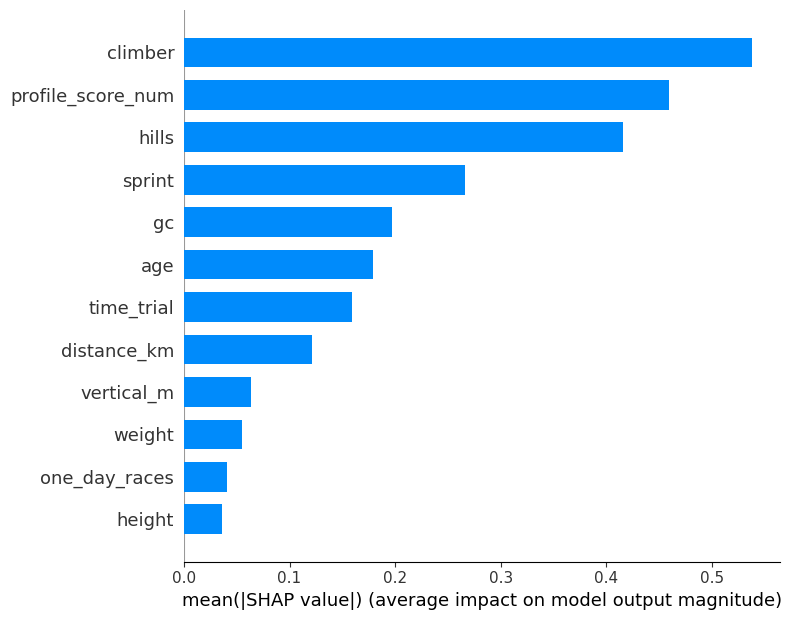

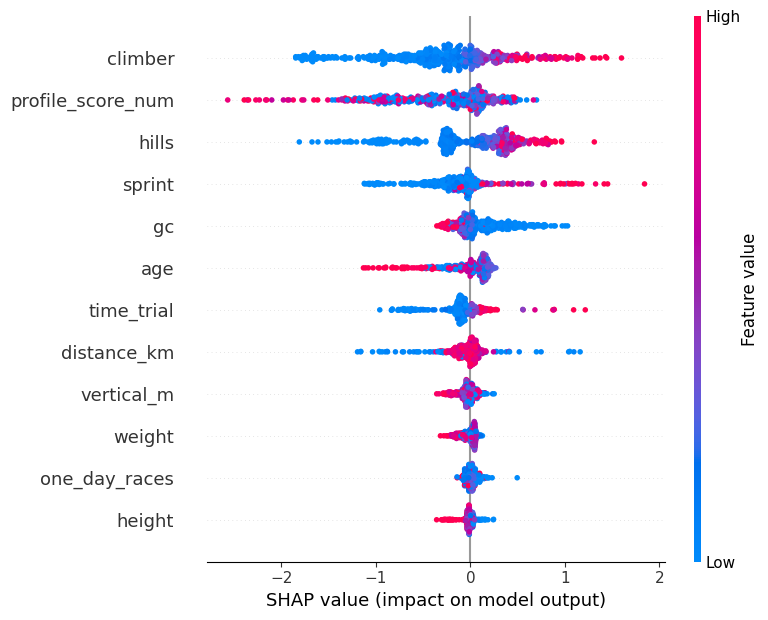

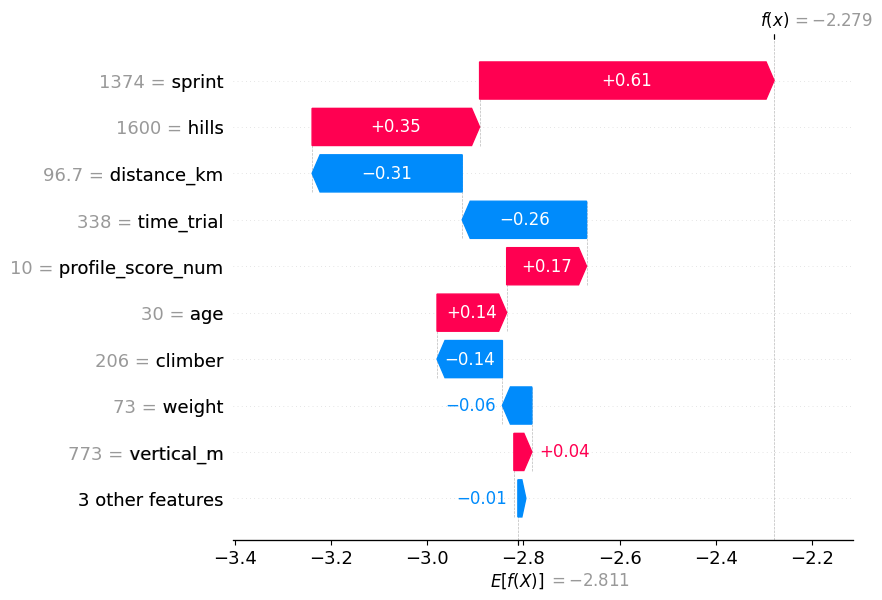

In [6]:
import shap

# Stichprobe ziehen, damit der Beeswarm-Plot lesbar bleibt
sample_idx = X_test.sample(min(500, len(X_test)), random_state=42).index
X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_sample)
expected_value = explainer.expected_value

# Globale Sicht: mittlere |SHAP|-Werte pro Feature
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=True)

# Verteilung der Beitraege pro Feature (Beeswarm)
shap.summary_plot(shap_values, X_sample, show=True)

# Lokale Erklaerung: Waterfall fuer eine einzelne Testbeobachtung.
# Macht die zentrale SHAP-Identitaet f(x) = phi_0 + sum_j phi_j visuell sichtbar:
# Start = E[f(X)], jede Zeile addiert den SHAP-Beitrag eines Features, Ende = Vorhersage.
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=expected_value,
    data=X_sample.iloc[0].values,
    feature_names=FEATURES,
)
shap.plots.waterfall(explanation, show=True)

### 6. LIME – Lokale modellagnostische Erklärungen

**Idee.** LIME (*Local Interpretable Model-agnostic Explanations*) approximiert die Vorhersage eines beliebigen Klassifikators **lokal** um eine konkrete Eingabe $x$ herum durch ein einfaches, interpretierbares Surrogatmodell $g$ – typischerweise eine sparse lineare Regression. Dazu werden perturbierte Nachbarn $z$ generiert, mit dem Originalmodell $f$ bewertet und mit einem Lokalitätskern $\pi_x(z)$ gewichtet. $g$ minimiert dann

$$\xi(x) = \arg\min_{g \in G}\; \mathcal{L}(f, g, \pi_x) + \Omega(g),$$

wobei $\Omega(g)$ die Komplexität des Surrogatmodells (z. B. Anzahl Nicht-Null-Koeffizienten) bestraft.

**Stärken.** Echt modellagnostisch – funktioniert für beliebige Klassifikatoren, auch jenseits von Baum-Ensembles. Liefert intuitive lokale Erklärungen pro Beobachtung.

**Schwächen.** Stark abhängig von Sampling-Strategie und Kernel-Wahl; Erklärungen können bei wiederholter Ausführung instabil sein. Aussagen gelten nur **lokal** in der Umgebung der erklärten Beobachtung – globale Modellaussagen lassen sich daraus nicht ableiten.

Vorhersage fuer diese Beobachtung: P(top10) = 0.554
LIME Top-Beitraege (Vorzeichen = Richtung, Betrag = Staerke):
  +0.066  sprint > 341.00
  +0.042  hills > 890.00
  -0.022  gc > 1963.00
  -0.012  age > 32.00
  -0.008  475.00 < climber <= 1410.00
  -0.004  weight > 73.00
  +0.003  one_day_races > 1513.00
  +0.002  distance_km <= 157.00


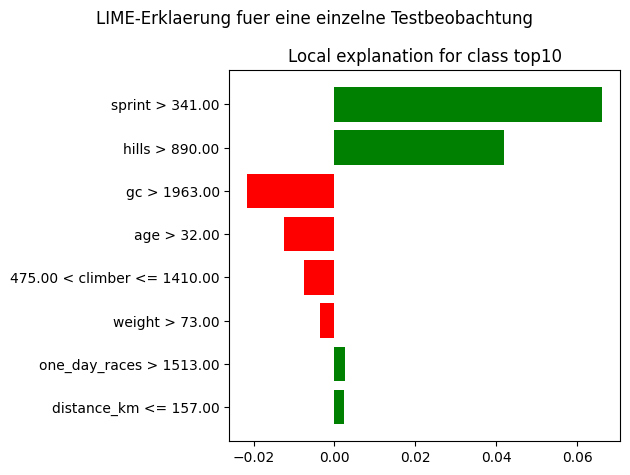

In [7]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURES,
    class_names=['no_top10', 'top10'],
    mode='classification',
    discretize_continuous=True,
    random_state=42,
)

# Beispielhaft eine einzelne Test-Zeile lokal erklaeren
sample_row = X_test.iloc[0].values
exp = lime_explainer.explain_instance(
    sample_row,
    xgb_clf.predict_proba,
    num_features=8,
)

# Modell-Wahrscheinlichkeit + LIME-Beitraege als Text ausgeben.
# So sieht man direkt, was das Modell vorhersagt UND wie LIME diese Vorhersage erklaert.
proba_top10 = xgb_clf.predict_proba(sample_row.reshape(1, -1))[0, 1]
print(f'Vorhersage fuer diese Beobachtung: P(top10) = {proba_top10:.3f}')
print('LIME Top-Beitraege (Vorzeichen = Richtung, Betrag = Staerke):')
for feat, weight in exp.as_list():
    print(f'  {weight:+.3f}  {feat}')

fig = exp.as_pyplot_figure()
fig.suptitle('LIME-Erklaerung fuer eine einzelne Testbeobachtung')
fig.tight_layout()
plt.show()

### 7. Direkter Vergleich (Klassifikation)

Die drei Klassifikatoren werden auf demselben `top10`-Task verglichen. Wir betrachten **Accuracy** und **ROC-AUC** – die kleine Demo-Pipeline ist nicht für valide Modellauswahl gedacht, sondern um die typischen Stärken/Schwächen sichtbar zu machen:

- **XGBoost**: gewöhnlich solide Performance, nutzt aber alle Features in komplexen Interaktionen → schwer interpretierbar.
- **EBM**: vergleichbare Genauigkeit bei voller Glass-Box-Interpretierbarkeit; Shape-Funktionen zeigen direkt den Effekt jedes Features.
- **TabPFN**: kein klassisches Training; auf kleinen Stichproben oft erstaunlich konkurrenzfähig, skaliert aber schlecht in die Breite/Tiefe.

In [8]:
results = {
    'XGBoost':  {'accuracy': xgb_acc,    'roc_auc': xgb_auc},
    'EBM':      {'accuracy': ebm_acc,    'roc_auc': ebm_auc},
    'TabPFN':   {'accuracy': tabpfn_acc, 'roc_auc': tabpfn_auc},
}

results_df = pd.DataFrame.from_dict(results, orient='index').round(3)
results_df.index.name = 'Modell'
results_df

,accuracy,roc_auc
Modell,,
XGBoost,0.939,0.853
EBM,0.938,0.848
TabPFN,0.934,0.773


### 8. XGBRanker – Learning-to-Rank

**Idee.** Klassifikation/Regression behandeln jede Beobachtung unabhängig. In unserem Use-Case („Wer fährt auf welchen Platz dieser Etappe?") sind die Beobachtungen aber *innerhalb einer Etappe* miteinander verknüpft: gewinnen kann nur einer, und es ist die *relative* Ordnung wichtig, nicht der absolute Wert. Genau hier setzt **Learning-to-Rank** (LTR) an.

`XGBRanker` mit `objective="rank:ndcg"` optimiert eine **paarweise / LambdaRank-Loss-Funktion**: für jedes Paar $(i, j)$ innerhalb derselben *Query-Gruppe* wird bestraft, wenn das Modell die im Label besser platzierte Beobachtung niedriger bewertet als die schlechter platzierte. Die Gewichtung der Paare folgt der **NDCG**-Verbesserung, die ein Tausch bringen würde.

**Query-Gruppen.** XGBoost erfährt über den `group=`-Vektor, welche Zeilen zusammengehören. Bei uns ist eine Etappe = Tupel `(race, year, stage_nr)`. Der `group`-Vektor enthält für jede Etappe die Anzahl Fahrer in dieser Etappe (in Reihenfolge der sortierten Daten).

**Zielmetrik.** **NDCG** (Normalized Discounted Cumulative Gain) misst, wie gut die ersten Treffer der vorhergesagten Reihenfolge mit den tatsächlich besten Platzierungen übereinstimmen.

**Unterschied zu Klassifikation/Regression.** Wir lernen keine absoluten Wahrscheinlichkeiten oder Werte, sondern eine *Score-Funktion*, deren konkrete Skala egal ist – relevant ist nur die induzierte Reihenfolge innerhalb jeder Etappe.

Als Label nehmen wir hier `relevance = max_rank − rank_num`, sodass ein höherer Score = besserer Platz gilt (NDCG erwartet höhere Labels = relevanter).

In [9]:
from xgboost import XGBRanker
from sklearn.metrics import ndcg_score

X_train_r = train_r[FEATURES]
X_test_r  = test_r[FEATURES]

# Relevance-Label: hoher Wert = besserer Platz (NDCG-konform).
# rank:ndcg in XGBoost nutzt den exponentiellen Gain und verlangt Labels <= 31.
# -> Wir clippen auf "Top-K relevante Beobachtungen" (alles ausserhalb hat Relevance 0).
TOP_K_REL = 15  # Labels in {0, 1, ..., 15}; 15 = Sieger, 0 = ausserhalb Top-15
y_train_r = np.maximum(0, TOP_K_REL + 1 - train_r['rank_num']).astype(int).to_numpy()
y_test_r  = np.maximum(0, TOP_K_REL + 1 - test_r['rank_num']).astype(int).to_numpy()

ranker = XGBRanker(
    objective='rank:ndcg',
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
)
ranker.fit(X_train_r, y_train_r, group=groups_train)

scores_test = ranker.predict(X_test_r)

# Pro Etappe NDCG@10 und Top-3-Trefferquote berechnen
ndcg_per_stage = []
top3_hits = []
offset = 0
stage_slices = []  # (slice, n_riders) merken fuer Case-Study unten
for g in groups_test:
    if g < 2:
        offset += g
        continue
    sl = slice(offset, offset + g)
    stage_slices.append((sl, g))
    y_true_g = y_test_r[sl].reshape(1, -1)
    s_g      = scores_test[sl].reshape(1, -1)
    k = min(10, g)
    ndcg_per_stage.append(ndcg_score(y_true_g, s_g, k=k))

    # Top-3-Trefferquote: Anteil der wirklichen Top-3, die auch im vorhergesagten Top-3 landen
    true_rank_stage = test_r['rank_num'].to_numpy()[sl]
    pred_order = np.argsort(-scores_test[sl])
    pred_top3 = set(pred_order[:3].tolist())
    true_top3 = set(np.argsort(true_rank_stage)[:3].tolist())
    top3_hits.append(len(pred_top3 & true_top3) / 3.0)
    offset += g

print(f'Mittleres NDCG@10 über Test-Etappen:  {np.mean(ndcg_per_stage):.3f}')
print(f'Mittlere Top-3-Trefferquote:           {np.mean(top3_hits):.3f}')
print(f'Anzahl ausgewerteter Etappen:          {len(ndcg_per_stage)}')

# === Case-Study: eine zufaellige Test-Etappe -> Top-3 echt vs. vorhergesagt ===
# Macht greifbar, was der Ranker innerhalb einer Query-Gruppe tut.
rng = np.random.default_rng(42)
sl_demo, g_demo = stage_slices[rng.integers(len(stage_slices))]
stage_meta = test_r.iloc[sl_demo].iloc[0]
print(f"\nBeispiel-Etappe: {stage_meta['race']} {int(stage_meta['year'])}, "
      f"Stage {int(stage_meta['stage_nr'])} ({g_demo} Fahrer)")

stage_view = test_r.iloc[sl_demo][['name', 'rank_num']].copy().reset_index(drop=True)
stage_view['ranker_score'] = scores_test[sl_demo].round(3)
stage_view['vorhergesagter_rang'] = stage_view['ranker_score'].rank(ascending=False, method='min').astype(int)

true_top3 = stage_view.sort_values('rank_num').head(3)[['name', 'rank_num']].reset_index(drop=True)
pred_top3 = stage_view.sort_values('ranker_score', ascending=False).head(3)[['name', 'ranker_score']].reset_index(drop=True)

print('\nEchte Top-3:')
print(true_top3.to_string(index=False))
print('\nVorhergesagte Top-3 (XGBRanker):')
print(pred_top3.to_string(index=False))

Mittleres NDCG@10 über Test-Etappen:  0.391
Mittlere Top-3-Trefferquote:           0.217
Anzahl ausgewerteter Etappen:          370

Beispiel-Etappe: giro-d-italia 2021, Stage 14 (158 Fahrer)

Echte Top-3:
             name  rank_num
Lorenzo Fortunato         1
      Jan Tratnik         2
  Alessandro Covi         3

Vorhergesagte Top-3 (XGBRanker):
           name  ranker_score
    Simon Yates         0.948
  Romain Bardet         0.632
Vincenzo Nibali         0.476


### 9. Fazit & Ausblick

**Wann welches Modell?**
- **XGBoost-Klassifikator**: gute Default-Wahl, wenn man schnell eine starke Baseline für tabellarische Klassifikation/Regression braucht und Interpretierbarkeit nachgelagert behandelt (z. B. via SHAP).
- **EBM**: ideal, wenn Erklärbarkeit selbst Teil des Modells sein muss – z. B. zur Argumentation gegenüber Coaches/Redaktion, *warum* ein Fahrer für eine Etappe als Favorit gilt. Performance liegt oft sehr nah an XGBoost.
- **TabPFN**: spannend, wenn der Datensatz klein ist oder ein „Out-of-the-box"-Modell ohne Tuning gefragt ist; aktuell in Größe/Feature-Anzahl begrenzt und am stärksten bei Klassifikation.
- **XGBRanker**: das Modell, das *strukturell* am besten zum eigentlichen Ziel passt, weil es Etappenrang als Ranking-Problem behandelt statt als Klassifikation/Regression.

**Ausblick.** Das nächste Notebook sollte sich auf Folgendes konzentrieren:
- Saubere **Hyperparameter-Suche** (z. B. Optuna/Cross-Validation auf zeitlich rollierenden Splits).
- Solides **Feature-Engineering** (Form-Indikatoren über `points_per_season_history`, Teamhistorie, Vorjahresergebnisse je Strecke).
- Konsequente **Ranking-Metriken** (NDCG@k, MAP, Top-k-Trefferquote pro Etappe) statt Accuracy.
- Eine durchgängige Pipeline aus Datenaufbereitung → Modelltraining → Evaluation → Visualisierung der Vorhersagen.

Dieses Notebook bleibt bewusst auf Theorie und Mini-Demos beschränkt; alle echten Ergebnisse entstehen in den Folge-Notebooks.